# 05 - Future Nutrition Condition and MUAC Prediction

## Objective

This notebook predicts a child's **future nutrition condition** and **future MUAC value** using historical Growth Monitoring Program (GMP) visit records.

The notebook uses two machine learning models:

1. **Random Forest Classifier** → predicts the future nutrition condition.
2. **Random Forest Regressor** → predicts the future MUAC value.

The prediction uses current visit information, previous MUAC history, MUAC change, and the selected prediction horizon in months.

## Step 1: Import Required Libraries

In [1]:
import os
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import GroupShuffleSplit
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

## Step 2: Load Dataset

This notebook uses `trend_ready_data.csv` because it contains full visit-level child history. This is required for future prediction.

In [2]:
# Load dataset safely from the project data folder
DATA_PATH = "../data/trend_ready_data.csv"

if not os.path.exists(DATA_PATH):
    DATA_PATH = "trend_ready_data.csv"

df = pd.read_csv(DATA_PATH)

print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (5080, 9)


,ID,GmpDate,Name,DOB,MUAC,Age_Months,Condition,Cluster,Cluster_Name
0,581415010001,2017-12-17,ff,2017-12-17,15.0,0.00,Good,0,Healthy
1,581415010001,2017-12-28,ff,2017-12-17,15.0,0.36,Good,0,Healthy
2,581415010002,2017-12-17,gg,2017-12-17,13.0,0.00,At Risk,1,Moderate Risk
3,581415010002,2017-12-28,gg,2017-12-17,14.0,0.36,Good,1,Moderate Risk
4,581415010004,2017-12-18,hskkd,2017-12-18,13.0,0.00,At Risk,1,Moderate Risk


## Step 3: Sort Visits by Child and Date

For future prediction, visit order is important. Therefore, records are sorted by child ID and GMP visit date.

In [3]:
df["GmpDate"] = pd.to_datetime(df["GmpDate"], errors="coerce")
df = df.sort_values(["ID", "GmpDate"])

print("Data sorted by ID and GmpDate")
df[["ID", "GmpDate", "MUAC", "Condition"]].head(10)

Data sorted by ID and GmpDate


,ID,GmpDate,MUAC,Condition
0,581415010001,2017-12-17,15.0,Good
1,581415010001,2017-12-28,15.0,Good
2,581415010002,2017-12-17,13.0,At Risk
3,581415010002,2017-12-28,14.0,Good
4,581415010004,2017-12-18,13.0,At Risk
5,581415010004,2017-12-28,15.0,Good
6,581415010035,2017-12-28,14.0,Good
7,581415010035,2018-07-19,15.4,Good
8,581494010009,2017-12-21,11.5,Moderate
9,581494010009,2017-12-27,15.0,Good


## Step 4: Create Visit-Based Features

The following features are generated from historical child visits:

- `Visit_Number`: visit sequence of each child
- `Previous_MUAC`: MUAC value from the previous visit
- `MUAC_Change`: change between current MUAC and previous MUAC
- `Previous_Date`: previous visit date
- `Month_Gap`: approximate month gap between current and previous visit

In [4]:
# Visit sequence for each child
df["Visit_Number"] = df.groupby("ID").cumcount() + 1

# Previous MUAC value
df["Previous_MUAC"] = df.groupby("ID")["MUAC"].shift(1)

# MUAC change from previous visit
df["MUAC_Change"] = df["MUAC"] - df["Previous_MUAC"]

# Previous visit date
df["Previous_Date"] = df.groupby("ID")["GmpDate"].shift(1)

# Month gap between current and previous visit
df["Month_Gap"] = (df["GmpDate"] - df["Previous_Date"]).dt.days / 30

# Show sample
df[["ID", "GmpDate", "Previous_Date", "Month_Gap", "MUAC", "Previous_MUAC", "MUAC_Change"]].head(10)

,ID,GmpDate,Previous_Date,Month_Gap,MUAC,Previous_MUAC,MUAC_Change
0,581415010001,2017-12-17,NaT,NaN,15.0,NaN,NaN
1,581415010001,2017-12-28,2017-12-17,0.366667,15.0,15.0,0.0
2,581415010002,2017-12-17,NaT,NaN,13.0,NaN,NaN
3,581415010002,2017-12-28,2017-12-17,0.366667,14.0,13.0,1.0
4,581415010004,2017-12-18,NaT,NaN,13.0,NaN,NaN
5,581415010004,2017-12-28,2017-12-18,0.333333,15.0,13.0,2.0
6,581415010035,2017-12-28,NaT,NaN,14.0,NaN,NaN
7,581415010035,2018-07-19,2017-12-28,6.766667,15.4,14.0,1.4
8,581494010009,2017-12-21,NaT,NaN,11.5,NaN,NaN
9,581494010009,2017-12-27,2017-12-21,0.200000,15.0,11.5,3.5


## Step 5: Create Future Prediction Targets

Two future targets are created:

1. `Next_Condition` → the nutrition condition in the next observed visit.
2. `Next_MUAC` → the MUAC value in the next observed visit.

These targets allow the model to learn future nutrition progression patterns.

In [5]:
# Future condition target
df["Next_Condition"] = df.groupby("ID")["Condition"].shift(-1)

# Future MUAC target
df["Next_MUAC"] = df.groupby("ID")["MUAC"].shift(-1)

# Remove rows without previous visit or future target
model_df = df.dropna(subset=[
    "Previous_MUAC",
    "MUAC_Change",
    "Month_Gap",
    "Next_Condition",
    "Next_MUAC"
]).copy()

print("Model Dataset Shape:", model_df.shape)
model_df[["ID", "Visit_Number", "MUAC", "Previous_MUAC", "MUAC_Change", "Month_Gap", "Condition", "Next_MUAC", "Next_Condition"]].head(10)

Model Dataset Shape: (2408, 16)


,ID,Visit_Number,MUAC,Previous_MUAC,MUAC_Change,Month_Gap,Condition,Next_MUAC,Next_Condition
11,581494010014,2,15.0,15.0,0.0,1.033333,Good,15.0,Good
28,581494080257,2,13.8,14.0,-0.2,0.100000,Good,13.0,At Risk
33,581494080400,2,13.0,13.0,0.0,0.133333,At Risk,14.3,Good
38,583547010005,2,12.0,12.0,0.0,0.333333,Moderate,10.0,Severe
65,583547140005,2,14.0,13.0,1.0,1.166667,Good,14.0,Good
66,583547140005,3,14.0,14.0,0.0,3.033333,Good,15.0,Good
69,583547140039,2,14.0,13.0,1.0,1.166667,Good,14.4,Good
70,583547140039,3,14.4,14.0,0.4,1.100000,Good,15.0,Good
71,583547140039,4,15.0,14.4,0.6,1.000000,Good,15.0,Good
74,583547140048,2,13.0,13.0,0.0,1.166667,At Risk,12.5,At Risk


## Step 6: Check Month Gap Distribution

This verifies the approximate time gap between GMP visits.

In [6]:
print(model_df["Month_Gap"].describe())

count    2408.000000
mean        1.521429
std         1.535244
min         0.033333
25%         0.933333
50%         1.000000
75%         1.808333
max        17.200000
Name: Month_Gap, dtype: float64


### Condition Encoding

Machine learning models cannot directly understand text labels. Therefore, both current and future nutrition conditions are converted into numeric values using Label Encoding.

* **Condition → Condition_Enc** (Input Feature)
* **Next_Condition → Next_Condition_Enc** (Target Variable)

Example:

| Condition | Encoded Value |
| --------- | ------------- |
| At Risk   | 0             |
| Good      | 1             |
| Moderate  | 2             |
| Severe    | 3             |

`Condition_Enc` is used as an input feature, while `Next_Condition_Enc` is used as the prediction target for the Random Forest classifier.


## Step 7: Encode Current and Future Nutrition Conditions

Machine learning models cannot directly understand text labels, so condition labels are encoded into numeric values.

- At Risk   → 0
- Good      → 1
- Moderate  → 2
- Severe    → 3

In [7]:
condition_encoder = LabelEncoder()
target_encoder = LabelEncoder()

model_df["Condition_Enc"] = condition_encoder.fit_transform(model_df["Condition"])
model_df["Next_Condition_Enc"] = target_encoder.fit_transform(model_df["Next_Condition"])

print("Current Condition Classes:", list(condition_encoder.classes_))
print("Target Condition Classes:", list(target_encoder.classes_))

# Show encoded target output clearly
print("Next_Condition encoding preview:")
display(model_df[["Next_Condition", "Next_Condition_Enc"]].head(10))

print("Next_Condition_Enc value counts:")
print(model_df["Next_Condition_Enc"].value_counts().sort_index())

Current Condition Classes: ['At Risk', 'Good', 'Moderate', 'Severe']
Target Condition Classes: ['At Risk', 'Good', 'Moderate', 'Severe']
Next_Condition encoding preview:


,Next_Condition,Next_Condition_Enc
11,Good,1
28,At Risk,0
33,Good,1
38,Severe,3
65,Good,1
66,Good,1
69,Good,1
70,Good,1
71,Good,1
74,At Risk,0


Next_Condition_Enc value counts:
Next_Condition_Enc
0     539
1    1678
2     134
3      57
Name: count, dtype: int64


## Step 8: Select Features and Targets

Features used by the models:

- MUAC
- Age_Months
- Visit_Number
- Cluster
- Previous_MUAC
- MUAC_Change
- Condition_Enc
- Month_Gap

Targets:

- `y = model_df["Next_Condition_Enc"]` → encoded future condition target for classification
- `y_muac = model_df["Next_MUAC"]` → future MUAC target for regression

`Next_Condition_Enc` is created in the previous step from `Next_Condition` using `LabelEncoder`.

In [8]:
features = [
    "MUAC",
    "Age_Months",
    "Visit_Number",
    "Cluster",
    "Previous_MUAC",
    "MUAC_Change",
    "Condition_Enc",
    "Month_Gap"
]

X = model_df[features]

# Classification target: encoded future condition
y = model_df["Next_Condition_Enc"]
y_condition = y

# Regression target: future MUAC value
y_muac = model_df["Next_MUAC"]

groups = model_df["ID"]

print("Feature shape:", X.shape)
print("Target shape:", y.shape)
print("MUAC target shape:", y_muac.shape)
print("Features:", features)

print("Target output preview (y = Next_Condition_Enc):")
display(pd.DataFrame({
    "Next_Condition": model_df["Next_Condition"].head(10),
    "Next_Condition_Enc": y.head(10)
}))

Feature shape: (2408, 8)
Target shape: (2408,)
MUAC target shape: (2408,)
Features: ['MUAC', 'Age_Months', 'Visit_Number', 'Cluster', 'Previous_MUAC', 'MUAC_Change', 'Condition_Enc', 'Month_Gap']
Target output preview (y = Next_Condition_Enc):


,Next_Condition,Next_Condition_Enc
11,Good,1
28,At Risk,0
33,Good,1
38,Severe,3
65,Good,1
66,Good,1
69,Good,1
70,Good,1
71,Good,1
74,At Risk,0


## Step 9: Train-Test Split using GroupShuffleSplit

`GroupShuffleSplit` is used because each child can have multiple visits. This prevents records from the same child appearing in both training and testing sets, reducing data leakage.

In [9]:
gss = GroupShuffleSplit(
    n_splits=1,
    test_size=0.2,
    random_state=42
)

train_idx, test_idx = next(gss.split(X, y_condition, groups=groups))

X_train = X.iloc[train_idx]
X_test = X.iloc[test_idx]

y_condition_train = y_condition.iloc[train_idx]
y_condition_test = y_condition.iloc[test_idx]

y_muac_train = y_muac.iloc[train_idx]
y_muac_test = y_muac.iloc[test_idx]

print("Training Shape:", X_train.shape)
print("Testing Shape:", X_test.shape)
print("Train Children:", model_df.iloc[train_idx]["ID"].nunique())
print("Test Children:", model_df.iloc[test_idx]["ID"].nunique())

Training Shape: (1967, 8)
Testing Shape: (441, 8)
Train Children: 632
Test Children: 158


## Step 10: Train Future Condition Prediction Model

A Random Forest Classifier is used to predict the future nutrition condition.

In [10]:
rf_condition = RandomForestClassifier(
    n_estimators=500,
    max_depth=20,
    random_state=42,
    class_weight="balanced"
)

rf_condition.fit(X_train, y_condition_train)

print("Future condition prediction model trained successfully")

Future condition prediction model trained successfully


## Step 11: Evaluate Future Condition Prediction Model

In [11]:
y_condition_pred = rf_condition.predict(X_test)

condition_accuracy = accuracy_score(y_condition_test, y_condition_pred)

print("Condition Prediction Accuracy:", round(condition_accuracy * 100, 2), "%")
print("Classification Report:")
print(classification_report(
    y_condition_test,
    y_condition_pred,
    target_names=target_encoder.classes_
))

Condition Prediction Accuracy: 76.42 %
Classification Report:
              precision    recall  f1-score   support

     At Risk       0.58      0.49      0.53       105
        Good       0.84      0.91      0.87       304
    Moderate       0.29      0.21      0.24        19
      Severe       0.57      0.31      0.40        13

    accuracy                           0.76       441
   macro avg       0.57      0.48      0.51       441
weighted avg       0.74      0.76      0.75       441



## Step 12: Confusion Matrix

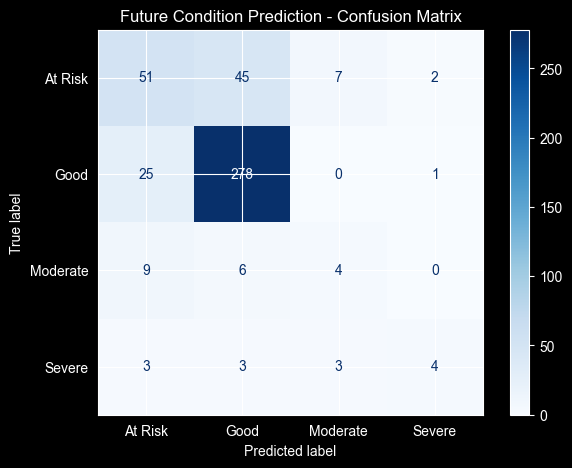

In [12]:
cm = confusion_matrix(y_condition_test, y_condition_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=target_encoder.classes_
)

fig, ax = plt.subplots(figsize=(7, 5))
disp.plot(ax=ax, cmap="Blues", values_format="d")
plt.title("Future Condition Prediction - Confusion Matrix")
plt.show()

## Step 13: Train Future MUAC Prediction Model

A Random Forest Regressor is used to predict the future MUAC value.

In [13]:
rf_muac = RandomForestRegressor(
    n_estimators=500,
    max_depth=20,
    random_state=42
)

rf_muac.fit(X_train, y_muac_train)

print("Future MUAC prediction model trained successfully")

Future MUAC prediction model trained successfully


## Step 14: Evaluate Future MUAC Prediction Model

Regression metrics are used to evaluate future MUAC prediction.

In [14]:
y_muac_pred = rf_muac.predict(X_test)

mae = mean_absolute_error(y_muac_test, y_muac_pred)
rmse = np.sqrt(mean_squared_error(y_muac_test, y_muac_pred))
r2 = r2_score(y_muac_test, y_muac_pred)

print("Future MUAC Prediction Evaluation")
print("--------------------------------")
print("MAE :", round(mae, 4))
print("RMSE:", round(rmse, 4))
print("R²  :", round(r2, 4))

Future MUAC Prediction Evaluation
--------------------------------
MAE : 0.7051
RMSE: 1.3273
R²  : 0.529


## Step 15: Feature Importance

Feature importance helps identify which factors contributed most to future condition prediction.

In [15]:
importance_df = pd.DataFrame({
    "Feature": features,
    "Importance": rf_condition.feature_importances_
}).sort_values("Importance", ascending=False)

importance_df

,Feature,Importance
1,Age_Months,0.202402
0,MUAC,0.172776
4,Previous_MUAC,0.150524
7,Month_Gap,0.146107
5,MUAC_Change,0.124952
2,Visit_Number,0.080494
6,Condition_Enc,0.077502
3,Cluster,0.045243


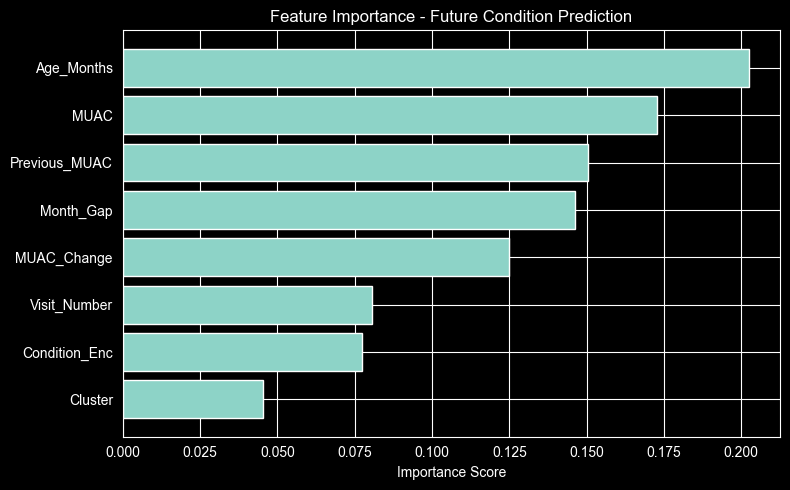

In [16]:
plt.figure(figsize=(8, 5))
plt.barh(importance_df["Feature"], importance_df["Importance"])
plt.gca().invert_yaxis()
plt.xlabel("Importance Score")
plt.title("Feature Importance - Future Condition Prediction")
plt.tight_layout()
plt.show()

## Step 16: Nutrition Recommendation Function

This function returns a recommendation based on the predicted future condition.

In [17]:
def get_recommendation(pred_condition):
    if pred_condition == "Good":
        return ("✅ Child is likely to remain or improve nutritionally.""• Continue regular growth monitoring.""• Maintain healthy feeding practices.""• Attend scheduled GMP visits."
        )

    if pred_condition == "At Risk":
        return ("⚠️ Child may become nutritionally at risk.""• Regular follow-up is recommended.""• Provide nutrition counseling to caregiver.""• Monitor MUAC closely."
        )

    if pred_condition == "Moderate":
        return ("🟠 Moderate nutrition risk predicted.""• Nutritional support is recommended.""• Increase monitoring frequency.""• Consult health worker if condition continues."
        )

    return (
        "🔴 Severe nutrition risk predicted.""• Immediate nutrition intervention is recommended.""• Refer to health worker or nutrition support program.""• Follow up urgently."
    )

## Step 17: User Input Based Future Prediction Function

This function predicts both:

1. Predicted Future MUAC
2. Predicted Future Condition

The prediction horizon is provided manually by the user in months.

In [18]:
def predict_future_condition(
    current_muac,
    previous_muac,
    age_months,
    visit_number,
    cluster,
    current_condition,
    prediction_horizon_months
):
    """
    Predict future MUAC and future nutrition condition using current visit information.
    """

    if current_condition not in condition_encoder.classes_:
        raise ValueError(
            f"Invalid current_condition: {current_condition}. "
            f"Allowed values: {list(condition_encoder.classes_)}"
        )

    muac_change = current_muac - previous_muac
    condition_enc = condition_encoder.transform([current_condition])[0]

    input_data = pd.DataFrame([{
        "MUAC": current_muac,
        "Age_Months": age_months,
        "Visit_Number": visit_number,
        "Cluster": cluster,
        "Previous_MUAC": previous_muac,
        "MUAC_Change": muac_change,
        "Condition_Enc": condition_enc,
        "Month_Gap": prediction_horizon_months
    }])

    # Future MUAC prediction
    predicted_future_muac = rf_muac.predict(input_data)[0]

    # Future condition prediction
    prediction_enc = rf_condition.predict(input_data)[0]
    probabilities = rf_condition.predict_proba(input_data)[0]

    predicted_condition = target_encoder.inverse_transform([prediction_enc])[0]
    confidence = probabilities[prediction_enc] * 100

    print("🔮 Future Nutrition Prediction Result")
    print("--------------------------------------------------")
    print("Current Visit Information")
    print(f"Current MUAC: {current_muac:.2f} cm")
    print(f"Previous MUAC: {previous_muac:.2f} cm")
    print(f"MUAC Change: {muac_change:.2f} cm")
    print(f"Age: {age_months} months")
    print(f"Visit Number: {visit_number}")
    print(f"Current Condition: {current_condition}")
    print("--------------------------------------------------")
    print(f"Prediction Horizon: {prediction_horizon_months} Months")
    print(f"Predicted Future MUAC: {predicted_future_muac:.2f} cm")
    print(f"Predicted Future Condition: {predicted_condition}")
    print(f"Confidence: {confidence:.2f}%")
    print("--------------------------------------------------")
    print("Prediction Probability:")

    for condition, prob in zip(target_encoder.classes_, probabilities):
        print(f"{condition:<9}: {prob * 100:.2f}%")

    print("--------------------------------------------------")
    print("Recommendation:")
    print(get_recommendation(predicted_condition))

    return {
        "predicted_future_muac": predicted_future_muac,
        "predicted_condition": predicted_condition,
        "confidence": confidence,
        "probabilities": dict(zip(target_encoder.classes_, probabilities))
    }

## Step 18: Example Prediction

Change the input values to test different child conditions and prediction horizons.

In [19]:
result = predict_future_condition(
    current_muac=14.50,
    previous_muac=14.50,
    age_months=16.32,
    visit_number=2,
    cluster=0,
    current_condition="Good",
    prediction_horizon_months=6
)

🔮 Future Nutrition Prediction Result
--------------------------------------------------
Current Visit Information
Current MUAC: 14.50 cm
Previous MUAC: 14.50 cm
MUAC Change: 0.00 cm
Age: 16.32 months
Visit Number: 2
Current Condition: Good
--------------------------------------------------
Prediction Horizon: 6 Months
Predicted Future MUAC: 14.26 cm
Predicted Future Condition: Good
Confidence: 96.00%
--------------------------------------------------
Prediction Probability:
At Risk  : 1.60%
Good     : 96.00%
Moderate : 0.00%
Severe   : 2.40%
--------------------------------------------------
Recommendation:
✅ Child is likely to remain or improve nutritionally.• Continue regular growth monitoring.• Maintain healthy feeding practices.• Attend scheduled GMP visits.


## Step 19: Child History Check by Manual ID

This section allows checking the visit history of any child ID from the dataset.

In [25]:
# Manually enter child ID
child_id = 581494080247

child_info = df[df["ID"] == child_id].sort_values("GmpDate")

show_columns = [
    "ID",
    "GmpDate",
    "Name",
    "DOB",
    "Age_Months",
    "MUAC",
    "Condition",
    "Cluster",
    "Cluster_Name",
    "Visit_Number",
    "Previous_MUAC",
    "MUAC_Change",
    "Month_Gap",
    "Next_Condition"
]

show_columns = [col for col in show_columns if col in df.columns]

if len(child_info) == 0:
    print("No records found for this child ID")
else:
    display(child_info[show_columns])

,ID,GmpDate,Name,DOB,Age_Months,MUAC,Condition,Cluster,Cluster_Name,Visit_Number,Previous_MUAC,MUAC_Change,Month_Gap,Next_Condition
19,581494080247,2017-12-06,shahim begum,2016-08-05,16.03,14.5,Good,1,Moderate Risk,1,NaN,NaN,NaN,Good
20,581494080247,2017-12-24,shahim begum,2016-08-05,16.62,14.5,Good,1,Moderate Risk,2,14.5,0.0,0.6,NaN


## Step 20: Save Final Models and Files

The trained models and encoders are saved for future GUI deployment.

In [21]:
os.makedirs("../models", exist_ok=True)
os.makedirs("../data", exist_ok=True)

joblib.dump(rf_condition, "../models/future_condition_model.pkl")
joblib.dump(rf_muac, "../models/future_muac_model.pkl")
joblib.dump(condition_encoder, "../models/condition_encoder.pkl")
joblib.dump(target_encoder, "../models/target_encoder.pkl")
joblib.dump(features, "../models/future_prediction_features.pkl")

model_df.to_csv("../data/final_prediction_dataset.csv", index=False)

print("All models, encoders, features, and GUI-ready dataset saved successfully")

All models, encoders, features, and GUI-ready dataset saved successfully
